In [108]:
import numpy as np
import matplotlib.pyplot as plt 
from astropy.table import Table
from scipy.stats import ttest_ind

In [109]:
data = Table.read("Planet_Lightcurve.fits", format="fits")

In [110]:
print(data.colnames)

#printing first 5 rows
print(data[:5])

time = data['time [days]']
flux = data['flux']
#print(len(time))

['time [days]', 'flux']
    time [days]            flux       
------------------- ------------------
               -0.3 0.9718556446853187
-0.2993993993993994  0.974430548606305
-0.2987987987987988 0.9696244442016453
-0.2981981981981982 0.9672472927361904
-0.2975975975975976 0.9739989623419928


## Adding a 10% outlier/Solar Flare

In [102]:
import matplotlib.patches as patches

x_poly = [-0.15, -0.15, -0.3, -0.3, -0.15 ]
y_poly = [0.97, 0.99, 0.98, 0.96, 0.97]

#make the verticies of the polygon into a coordinate points 
coords = np.column_stack((x_poly, y_poly))
   #print(coords)
   #print(coords.shape)

poly_coords = np.zeros(shape=(len(x_poly),2))
poly_coords[:,0] = x_poly
poly_coords[:,1] = y_poly

poly = patches.Polygon(coords)

#test if some point is insid the polygon  
  #point = (-0.2993993993993994,  0.974430548606305)
  #print(poly.contains_point(point))

#make data into coordinates 
point_coords = np.column_stack((time, flux))
  #print(point_coords)

#see which point are insdie the polygon
is_inpoly = poly.contains_points(point_coords)
    #print(is_inpoly)
    #print(len(is_inpoly))

#index the list of points that are inside the polygon
time_inpoly = time[is_inpoly]
flux_inpoly = flux[is_inpoly]
    #print(len(time_inpoly)) = 230

#Add an outlier that is 10% brighter than the average 
avgflux_inpoly = np.mean(flux_inpoly)
flare_flux = avgflux_inpoly * 1.10

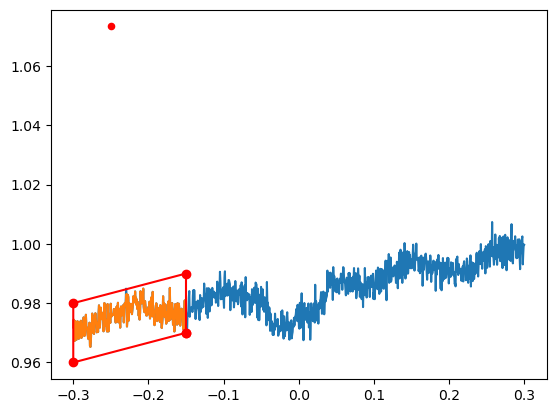

In [111]:
plt.errorbar(time, flux, yerr = None, xerr=None)
plt.errorbar(time_inpoly, flux_inpoly)

plt.scatter(-0.25, flare_flux, c='red', s=20)
#drawing this polygon
x_poly = [-0.15, -0.15, -0.3, -0.3, -0.15 ]
y_poly = [0.97, 0.99, 0.98, 0.96, 0.97]
plt.plot(x_poly, y_poly, '-o', c='r', zorder=10)

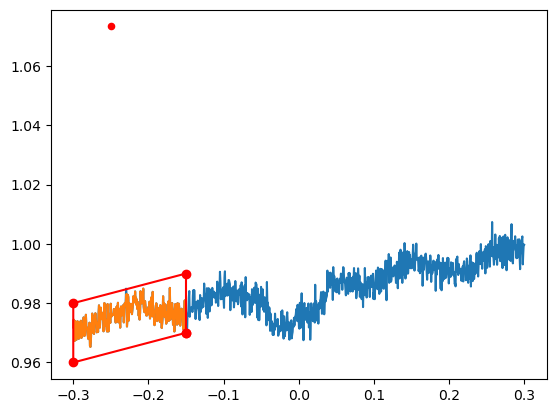

In [51]:
plt.errorbar(time, flux, yerr = None, xerr=None)
plt.errorbar(time_inpoly, flux_inpoly)

plt.scatter(-0.25, flare_flux, c='red', s=20)
#drawing this polygon
x_poly = [-0.15, -0.15, -0.3, -0.3, -0.15 ]
y_poly = [0.97, 0.99, 0.98, 0.96, 0.97]
plt.plot(x_poly, y_poly, '-o', c='r', zorder=10)

In [60]:
print(flare_flux)

1.073317415088485


In [90]:
#finding the n-sigma event 
std_inpoly = np.std(flux_inpoly)

mean_inpoly = np.mean(flux_inpoly)


n_sigma = (flare_flux - mean_inpoly) / std_inpoly
print(n_sigma)
print(f"The 10% solar flare is a {n_sigma:.4f}-sigma event")

25.248942978280336
The 10% solar flare is a 25.2489-sigma event


## Chauvenet's Criterion

In [95]:
#Chauvenet's Criterion
from scipy.special import erf

def event_probability(x, mu=0.0, s=1.0):

    z = np.fabs( (x-mu)/s)
    
    def zfunc(x):
        return 0.5*(1.0 + erf(x/2**0.5))
    
    return 1.0 - (zfunc(z) - zfunc(-1*z))

def chauvenet_criterion(prior_measurment, outlier):

    mean = np.nanmean(prior_measurment)
    std = np.nanstd(prior_measurment)

    outlier_probability = event_probability(outlier, mu=mean, s=std)
    
    N = len(prior_measurment) + 1

    if (N*outlier_probability< 0.5):
        if (outlier_probability < 1./float(2*N)):
            return True

    return False

In [97]:
answer = chauvenet_criterion(np.asarray(flux_inpoly), flare_flux)
print(f"Can we reject a solar flare that is 10% brighter? {answer}")

Can we reject a solar flare that is 10% brighter? True
